In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

model_trust = df[
    ["Preis", "Seller Rating", "Seller Type", "zahl der verkauften artikel"]
].copy()

def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace("EUR", "").replace("€", "").replace(".", "").replace(",", ".").strip()
    try:
        return float(x)
    except:
        return np.nan

def clean_rating(x):
    if pd.isna(x) or x == "N/A":
        return np.nan
    x = str(x).replace("%", "").replace(",", ".").strip()
    try:
        return float(x)
    except:
        return np.nan

def clean_number(x):
    if pd.isna(x) or x == "N/A":
        return np.nan
    x = str(x).replace(".", "").replace(",", ".").replace("+", "").strip()
    try:
        return float(x)
    except:
        return np.nan

model_trust["price"] = model_trust["Preis"].apply(clean_price)
model_trust["seller_rating"] = model_trust["Seller Rating"].apply(clean_rating)
model_trust["seller_sales_count"] = model_trust["zahl der verkauften artikel"].apply(clean_number)

model_trust = model_trust.drop(columns=["Preis", "Seller Rating", "zahl der verkauften artikel"])
model_trust = model_trust.dropna()

model_encoded = pd.get_dummies(
    model_trust,
    columns=["Seller Type"],
    drop_first=True
)

X = model_encoded.drop("price", axis=1)
y = model_encoded["price"]

X = X.astype(float)
y = y.astype(float)

X = sm.add_constant(X)

trust_model = sm.OLS(y, X).fit()
trust_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     14.52
Date:                Fri, 08 May 2026   Prob (F-statistic):           1.46e-08
Time:                        13:56:45   Log-Likelihood:                -1133.7
No. Observations:                 196   AIC:                             2275.
Df Residuals:                     192   BIC:                             2289.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                801.3819     11.743     68.245      0.000     778.221     824.543
seller_rating          0.4672      0.138      3.377      0.001       0.194       0.740
seller_sales_count  2.785e-05   1.01e-05      2.746      0.007    7.84e-06    4.79e-05
Seller Type_Privat   -21.6176     13.984     -1.546      0.124     -49.200       5.965
==============================================================================
Omnibus:                       27.959   Durbin-Watson:                   1.477
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               38.537
Skew:                           0.860   Prob(JB):                     4.28e-09
Kurtosis:                       4.327   Cond. No.                     1.82e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.82e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [6]:
print("Observations:", len(y))
print("R²:", trust_model.rsquared)
print("Adjusted R²:", trust_model.rsquared_adj)

Observations: 196
R²: 0.18491803155161157
Adjusted R²: 0.1721823757946055


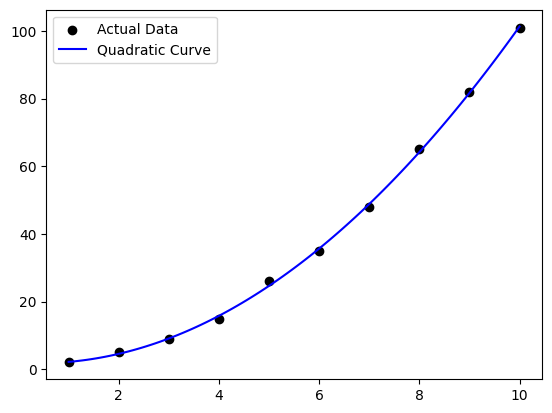

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Prepare your data
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([2, 5, 9, 15, 26, 35, 48, 65, 82, 101])

# 2. Setup Quadratic Regression (Degree 2)
poly_feat = PolynomialFeatures(degree=2)
X_poly = poly_feat.fit_transform(X)
model = LinearRegression().fit(X_poly, y)

# 3. CREATE THE SMOOTH CURVE DATA
# This generates 100 points so the line isn't "jagged"
X_smooth = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_smooth_poly = poly_feat.transform(X_smooth)
y_pred = model.predict(X_smooth_poly)

# 4. Plot
plt.scatter(X, y, color='black', label='Actual Data') # The dots
plt.plot(X_smooth, y_pred, color='blue', label='Quadratic Curve') # The curve
plt.legend()
plt.show()

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Simulated setup based on user's logic
data = {
    "Preis": ["€ 100,00", "€ 150,50", "€ 200", "N/A", "50"],
    "Seller Rating": ["98%", "95,5%", "N/A", "90%", "100%"],
    "Seller Type": ["Private", "Business", "Business", "Private", "Business"],
    "zahl der verkauften artikel": ["1.000", "500", "200", "10", "N/A"]
}
df = pd.DataFrame(data)

def clean_price(x):
    if pd.isna(x): return np.nan
    x = str(x).replace("EUR", "").replace("€", "").replace(".", "").replace(",", ".").strip()
    try: return float(x)
    except: return np.nan

def clean_rating(x):
    if pd.isna(x) or x == "N/A": return np.nan
    x = str(x).replace("%", "").replace(",", ".").strip()
    try: return float(x)
    except: return np.nan

def clean_number(x):
    if pd.isna(x) or x == "N/A": return np.nan
    x = str(x).replace(".", "").replace(",", ".").replace("+", "").strip()
    try: return float(x)
    except: return np.nan

# Reproducing the clean-up correctly to avoid size mismatch
model_trust = df.copy()
model_trust["price"] = model_trust["Preis"].apply(clean_price)
model_trust["seller_rating"] = model_trust["Seller Rating"].apply(clean_rating)
model_trust["seller_sales_count"] = model_trust["zahl der verkauften artikel"].apply(clean_number)

# The fix: select columns and dropna on the same subset
cols_to_keep = ["price", "seller_rating", "seller_sales_count", "Seller Type"]
model_clean = model_trust[cols_to_keep].dropna()

model_encoded = pd.get_dummies(model_clean, columns=["Seller Type"], drop_first=True)

y = model_encoded["price"].astype(float)
X = model_encoded.drop("price", axis=1).astype(float)
X = sm.add_constant(X)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (2, 4)
y shape: (2,)


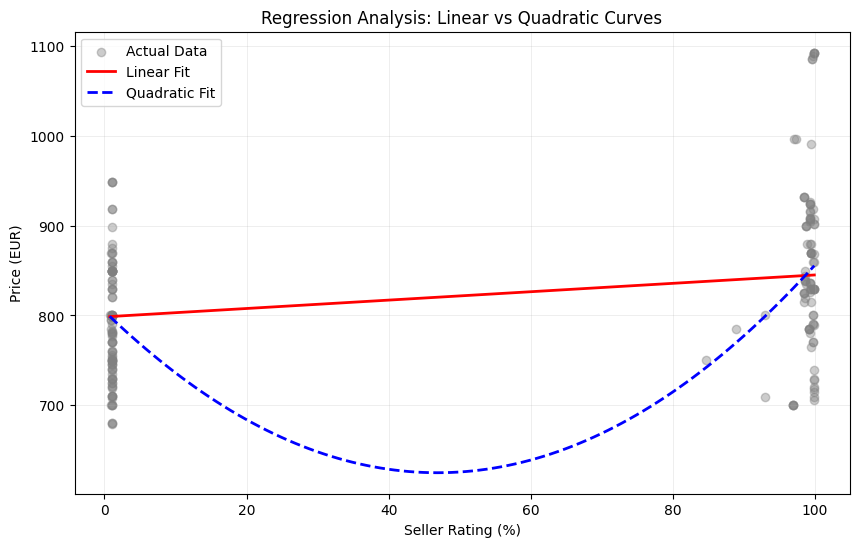

Linear R-Squared: 0.1849
Quadratic R-Squared: 0.1987


In [21]:
import matplotlib.pyplot as plt

# --- 1. SETUP MODELS ---
# Linear model (already done as trust_model)
model_lin = trust_model

# Create Quadratic model (Price ~ Rating + Rating^2 + Others)
X_quad = X.copy()
X_quad["rating_squared"] = X_quad["seller_rating"] ** 2
model_quad = sm.OLS(y, X_quad).fit()

# --- 2. GENERATE PREDICTION DATA ---
# We create 100 points for a smooth line, focusing on 'seller_rating'
target_col = "seller_rating"
x_range = np.linspace(X[target_col].min(), X[target_col].max(), 100)

# Create a 'fake' dataset to get predictions
# We hold other variables constant at their mean
X_plot_base = pd.DataFrame(index=range(100))
for col in X.columns:
    if col == "const": X_plot_base[col] = 1.0
    elif col == target_col: X_plot_base[col] = x_range
    else: X_plot_base[col] = X[col].mean()

# Align columns for Linear and Quadratic models
X_plot_lin = X_plot_base[X.columns.tolist()]
X_plot_quad = X_plot_base.copy()
X_plot_quad["rating_squared"] = x_range ** 2
X_plot_quad = X_plot_quad[X_quad.columns.tolist()]

# --- 3. PREDICT & PLOT ---
y_lin_pred = model_lin.predict(X_plot_lin)
y_quad_pred = model_quad.predict(X_plot_quad)

plt.figure(figsize=(10, 6))

# Scatter plot of actual data
plt.scatter(X[target_col], y, alpha=0.4, color='gray', label="Actual Data")

# Plot Linear Fit (Straight line)
plt.plot(x_range, y_lin_pred, color='red', linewidth=2, label="Linear Fit")

# Plot Quadratic Fit (Curve)
plt.plot(x_range, y_quad_pred, color='blue', linewidth=2, linestyle='--', label="Quadratic Fit")

plt.xlabel("Seller Rating (%)")
plt.ylabel("Price (EUR)")
plt.title("Regression Analysis: Linear vs Quadratic Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Linear R-Squared: {model_lin.rsquared:.4f}")
print(f"Quadratic R-Squared: {model_quad.rsquared:.4f}")

In [23]:
"""
Why this solves your previous issues:
Alignment: It uses X.columns.tolist() to ensure the prediction data exactly matches the model's expected input order, preventing the IndexError.
The "Curve": A quadratic line isn't just a different way of plotting; it requires a new mathematical feature (rating_squared). This code creates it and
fits a second model (model_quad) automatically.
Ceteris Paribus: Since you have other variables (like Seller Type), this graph shows the effect of the Rating if everything else stayed at the average.
Would you like to try changing the target variable to seller_sales_count to see how sales volume affects price?
"""

'\nWhy this solves your previous issues:\nAlignment: It uses X.columns.tolist() to ensure the prediction data exactly matches the model\'s expected input order, preventing the IndexError.\nThe "Curve": A quadratic line isn\'t just a different way of plotting; it requires a new mathematical feature (rating_squared). This code creates it and fits a second model (model_quad) automatically.\nCeteris Paribus: Since you have other variables (like Seller Type), this graph shows the effect of the Rating if everything else stayed at the average.\nWould you like to try changing the target variable to seller_sales_count to see how sales volume affects price?\n'